## 首先导入我们需要的数据文件（使用完整路径）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

注意要把路径改为自己本地的保存路径

In [2]:

customers = pd.read_csv('/Users/junyuliang/Downloads/E-commerce Customer Transaction Dataset/olist_customers_dataset.csv')

order_items = pd.read_csv('/Users/junyuliang/Downloads/E-commerce Customer Transaction Dataset/olist_order_items_dataset.csv')

orders = pd.read_csv('/Users/junyuliang/Downloads/E-commerce Customer Transaction Dataset/olist_orders_dataset.csv')



## 下面针对几个核心的数据文件预处理


### 先看看数据长什么样

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
print(orders.columns)   
print(order_items.columns)  

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')


### 接下来查找一下有无缺失值

In [6]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

可以看到只有order_approved_at （订单批准时间）   
order_delivered_carrier_date  （订单发货时间）
order_delivered_customer_date  （订单到货时间）
order_estimated_delivery_date （订单预期到货时间）有空值，
但这些列都是可以正常存在空值的，所以没有影响

### 一个订单如果被取消或未送达，它不应该被计入客户的消费历史。所以我们应该优先过滤掉这些无效订单。

In [8]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 为了保证数据的准确性，我们这里仅将‘delivered’认为是有效订单，下面把这些有效订单拿出来

In [9]:
valid_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"原始订单数: {len(orders)}")
print(f"有效订单数: {len(valid_orders)}")
print(f"排除的订单数: {len(orders) - len(valid_orders)}")

原始订单数: 99441
有效订单数: 96478
排除的订单数: 2963


### 再检查一下‘prcie’列是否有异常值（比如小于等于0的值）

In [10]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [11]:
valid_items = order_items[order_items['order_id'].isin(valid_orders['order_id'])]

In [12]:
valid_orders.shape   # 查看有效订单表有多少行、多少列

(96478, 8)

In [13]:
valid_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [14]:
valid_items.shape    # 查看有效商品明细表有多少行、多少列

(110197, 7)

In [15]:
# 检查 valid_orders 表中 order_id 是否唯一
valid_orders['order_id'].duplicated().sum()

np.int64(0)

In [16]:
# 检查 valid_items 表中 order_id 是否唯一
valid_items['order_id'].duplicated().sum()

np.int64(13719)

发现valid_orders的order_id唯一，但valid_items的order_id不唯一（这是因为valid_items表中并不是以order_id为key，而是以order_id和product_id为key）

In [17]:
# 按订单汇总，计算每个订单的总金额
order_amount = valid_items.groupby('order_id')['price'].sum().reset_index()
order_amount.columns = ['order_id', 'order_total']
order_amount.head()

,order_id,order_total
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


再将订单总金额order_total这一列加入到valid_orders

In [18]:
# 把订单总金额合并到 valid_orders 表中
orders_with_amount = valid_orders.merge(order_amount, on='order_id', how='inner')
orders_with_amount.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_total
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90


设置分析截止日期：计算R值需要知道“客户最后一次购买离今天过去了多少天”。但数据集中没有“今天”这个日期，所以用数据集最晚订单日期的后一天作为分析基准日。

In [19]:
# 第1步：转换日期格式
orders_with_amount['order_purchase_timestamp'] = pd.to_datetime(orders_with_amount['order_purchase_timestamp'])

# 第2步：计算截止日期
snapshot_date = orders_with_amount['order_purchase_timestamp'].max() + dt.timedelta(days=1)

In [20]:
rfm = orders_with_amount.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # R
    'order_id': 'count',                                                   # F
    'order_total': 'sum'                                                   # M
}).reset_index()

# 重命名列
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# 查看结果
rfm.head(5)


,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,89.80
1,000161a058600d5901f007fab4c27140,410,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,548,1,179.99
3,0002414f95344307404f0ace7a26f1d5,379,1,149.90
4,000379cdec625522490c315e70c7a9fb,150,1,93.00


这里出现了一个问题，似乎所有客户的Frequency都为1，也就是所有客户都只购买了一次，下面验证一下

In [21]:
rfm['Frequency'].value_counts().sort_index()

Frequency
1    96478
Name: count, dtype: int64

In [22]:
# 统计每个客户在 valid_orders 中出现的次数
customer_order_counts = valid_orders['customer_id'].value_counts()

# 查看频率前10名
print("每个客户的订单数分布（前10）：")
print(customer_order_counts.head(10))

# 查看频率分布
print("\n客户订单数统计：")
print(customer_order_counts.describe())

每个客户的订单数分布（前10）：
customer_id
9ef432eb6251297304e76186b10a928d    1
f8b67d327058afa39382991d7173b1d7    1
12ca54ef905df73b98dcf7ccb0b92d92    1
c840e43d3d57dbb4e99374570f2488cd    1
96c6a3143d7cc33bbebf14ab6abed0ce    1
eb4350b67a0264c67e5e06a038e4afbb    1
622b07d262d545d16efbd4363a89cb91    1
c701fbfa77791abd05eef9eacf7ea7a8    1
99ce553a3ac79b26416f2adca143760e    1
50900ea3519ead20da341b41081736e9    1
Name: count, dtype: int64

客户订单数统计：
count    96478.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: count, dtype: float64


结果是每个用户都只进行了一次消费

In [23]:
# 查看被排除的订单（非 delivered 状态）
excluded_orders = orders[orders['order_status'] != 'delivered']
excluded_counts = excluded_orders['customer_id'].value_counts()
print("被排除订单中，买过2次以上的客户数：", (excluded_counts >= 2).sum())

被排除订单中，买过2次以上的客户数： 0


In [24]:
# 检查 valid_orders 中的订单是否都在 order_items 中有记录
orders_in_items = valid_orders['order_id'].isin(order_items['order_id']).sum()
print(f"valid_orders 中的订单数: {len(valid_orders)}")
print(f"在 order_items 中有记录的订单数: {orders_in_items}")
print(f"被排除的订单数: {len(valid_orders) - orders_in_items}")

valid_orders 中的订单数: 96478
在 order_items 中有记录的订单数: 96478
被排除的订单数: 0


以上情况确实验证了每个用户都只进行了一次消费。

### 事实上，这样我们就无法进行用户购买的频率分析了，但仍可以进行R（最近购买天数）和M（消费金额）的分析，下面对r和m进行打分

In [25]:
# 给 Recency 打分（天数越少，分数越高）
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# 给 Monetary 打分（金额越高，分数越高）
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 查看打分结果
rfm[['customer_id', 'Recency', 'R_score', 'Monetary', 'M_score']].head()

,customer_id,Recency,R_score,Monetary,M_score
0,00012a2ce6f8dcda20d059ce98491703,288,2,89.80,3
1,000161a058600d5901f007fab4c27140,410,1,54.90,2
2,0001fd6190edaaf884bcaf3d49edf079,548,1,179.99,5
3,0002414f95344307404f0ace7a26f1d5,379,2,149.90,4
4,000379cdec625522490c315e70c7a9fb,150,4,93.00,3


### 注：这里我使用了qcut函数进行等数量分层，但是在实际中可以根据业务需要设置阈值

In [26]:
# R分数：基于天数间隔（示例规则，可调整）
def calc_r_score(days):
    if days <= 30: return 5
    elif days <= 60: return 4
    elif days <= 90: return 3
    elif days <= 180: return 2
    else: return 1

rfm['R_score_rule'] = rfm['Recency'].apply(calc_r_score)

# M分数：基于金额分位数或业务阈值（示例）
def calc_m_score(amount):
    if amount >= 500: return 5
    elif amount >= 300: return 4
    elif amount >= 150: return 3
    elif amount >= 50: return 2
    else: return 1

rfm['M_score_rule'] = rfm['Monetary'].apply(calc_m_score)

接着根据打分结果给用户分层

In [27]:
# 定义分层函数
def customer_segment(row):
    # 高价值活跃：最近买过 + 花钱多
    if row['R_score'] >= 4 and row['M_score'] >= 4:
        return '高价值活跃客户'
    # 潜力客户：最近买过 + 花钱中等
    elif row['R_score'] >= 4 and row['M_score'] >= 2:
        return '潜力客户'
    # 高价值流失风险：很久没买 + 花钱多
    elif row['R_score'] <= 2 and row['M_score'] >= 4:
        return '高价值流失风险'
    # 低价值流失：很久没买 + 花钱少
    elif row['R_score'] <= 2 and row['M_score'] <= 2:
        return '低价值流失客户'
    # 一般客户
    else:
        return '一般客户'

# 应用分层
rfm['Segment'] = rfm.apply(customer_segment, axis=1)

# 查看各层级客户数量
print(rfm['Segment'].value_counts())

Segment
一般客户       34625
高价值活跃客户    16013
低价值流失客户    15889
潜力客户       15028
高价值流失风险    14923
Name: count, dtype: int64


### 下面是一些可视化

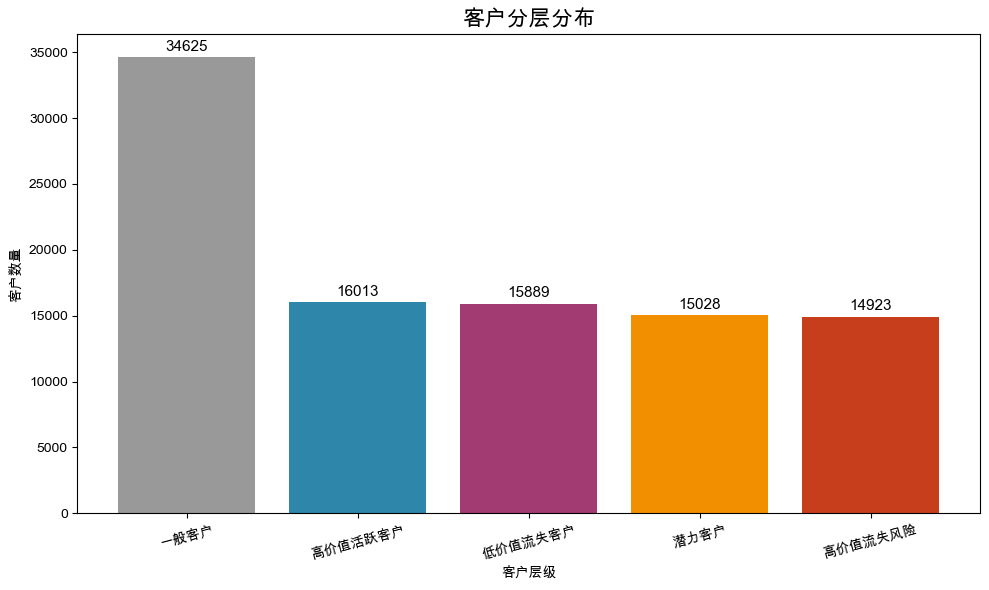

In [28]:

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'STHeiti', 'PingFang SC']

# 分层数据
segments = ['一般客户', '高价值活跃客户', '低价值流失客户', '潜力客户', '高价值流失风险']
counts = [34625, 16013, 15889, 15028, 14923]
colors = ['#999999', '#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# 柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(segments, counts, color=colors)
plt.title('客户分层分布', fontsize=16)
plt.xlabel('客户层级')
plt.ylabel('客户数量')
plt.xticks(rotation=15)

# 在柱子上方显示数字
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height())}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

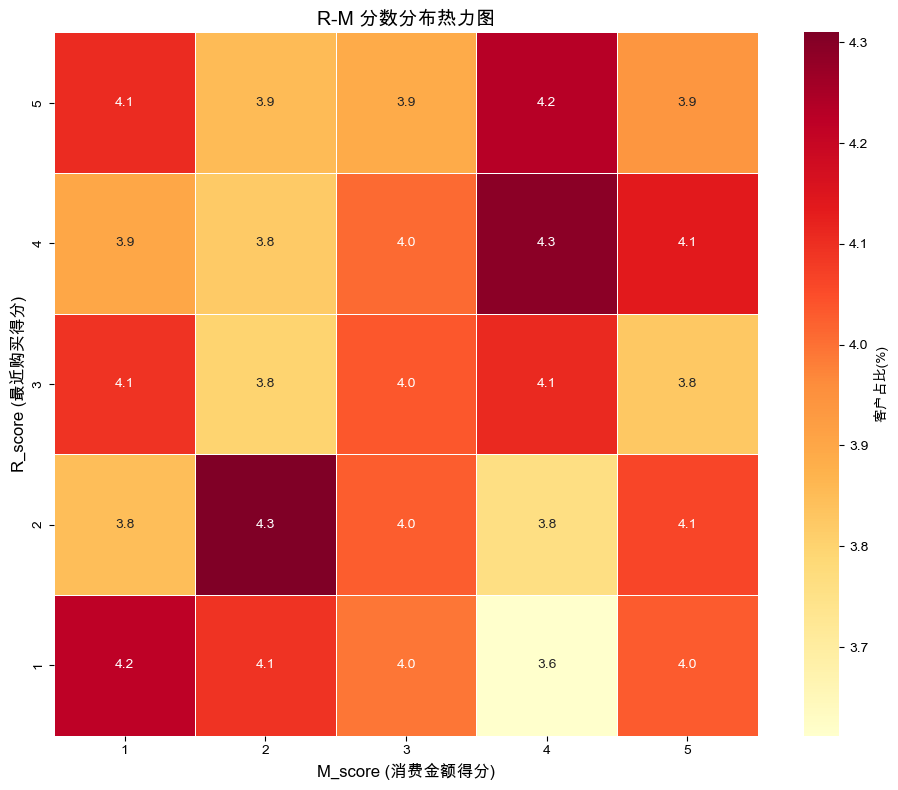

In [29]:

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'STHeiti', 'PingFang SC']

# 创建R_score和M_score的交叉表
heatmap_data = pd.crosstab(rfm['R_score'], rfm['M_score'], normalize='all') * 100

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            square=True, linewidths=0.5,
            cbar_kws={'label': '客户占比(%)'})
plt.title('R-M 分数分布热力图', fontsize=14, fontweight='bold')
plt.xlabel('M_score (消费金额得分)', fontsize=12)
plt.ylabel('R_score (最近购买得分)', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/nh/w0bg50gn70v04m_txsb_fvcc0000gn/T/ipykernel_17748/1454616688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segment_en', y='Recency', ax=axes[0], palette='Set2', order=segment_en)
/var/folders/nh/w0bg50gn70v04m_txsb_fvcc0000gn/T/ipykernel_17748/1454616688.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segment_en', y='Monetary', ax=axes[1], palette='Set2', order=segment_en)


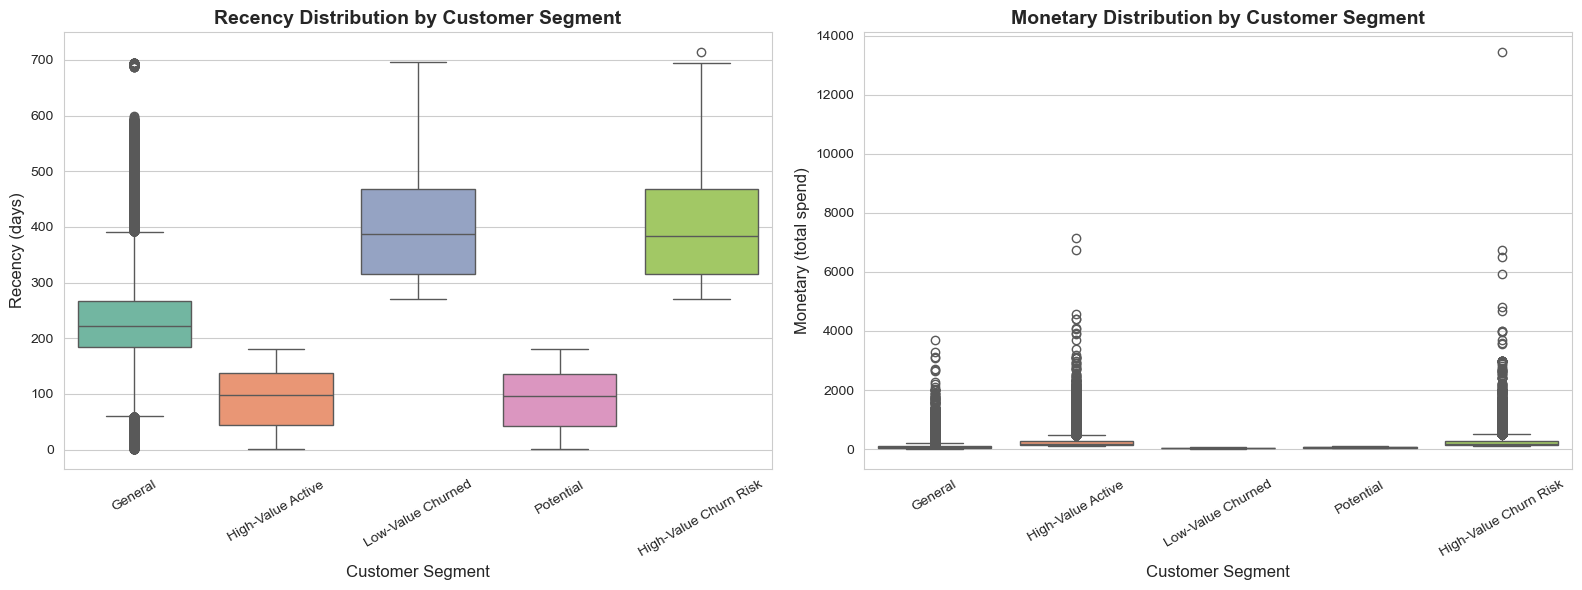

In [30]:

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_order = ['一般客户', '高价值活跃客户', '低价值流失客户', '潜力客户', '高价值流失风险']
segment_en = ['General', 'High-Value Active', 'Low-Value Churned', 'Potential', 'High-Value Churn Risk']

# 创建英文映射
segment_map = dict(zip(segment_order, segment_en))
rfm['Segment_en'] = rfm['Segment'].map(segment_map)

# 图1：Recency 箱线图
sns.boxplot(data=rfm, x='Segment_en', y='Recency', ax=axes[0], palette='Set2', order=segment_en)
axes[0].set_title('Recency Distribution by Customer Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer Segment', fontsize=12)
axes[0].set_ylabel('Recency (days)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# 图2：Monetary 箱线图
sns.boxplot(data=rfm, x='Segment_en', y='Monetary', ax=axes[1], palette='Set2', order=segment_en)
axes[1].set_title('Monetary Distribution by Customer Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Segment', fontsize=12)
axes[1].set_ylabel('Monetary (total spend)', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 下面我们再做一个分析：探寻高价值用户的偏爱产品，这时需要用到数据集的另外一些表

In [31]:
# 加载产品表和品类翻译表
products = pd.read_csv('/Users/junyuliang/Downloads/E-commerce Customer Transaction Dataset/olist_products_dataset.csv')
category_translation = pd.read_csv('/Users/junyuliang/Downloads/E-commerce Customer Transaction Dataset/product_category_name_translation.csv')

# 查看产品表有哪些列
print("=== 产品表列名 ===")
print(products.columns.tolist())

# 查看品类翻译表列名
print("\n=== 品类翻译表列名 ===")
print(category_translation.columns.tolist())

# 查看两个表的前几行
print("\n=== 产品表前3行 ===")
print(products.head(3))

print("\n=== 品类翻译表前3行 ===")
print(category_translation.head(3))

=== 产品表列名 ===
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

=== 品类翻译表列名 ===
['product_category_name', 'product_category_name_english']

=== 产品表前3行 ===
                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5            perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                 artes   
2  96bd76ec8810374ed1b65e291975717f         esporte_lazer   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  

orders表中有order_id和customer_id，orders_items表中有order_id和product_id列，而products表中有product_id和product_category_name。对这三个表进行多表关联。关键字段：orders.order_id = order_items.order_id ，order_items.product_id = products.product_id

In [32]:
# 1. 先关联 orders 和 order_items（通过 order_id）
orders_items_merged = valid_orders.merge(order_items, on='order_id', how='inner')

# 2. 再关联 products（通过 product_id）
orders_items_products = orders_items_merged.merge(products[['product_id', 'product_category_name']], 
                                                   on='product_id', how='left')

# 3. 最后关联 rfm 表获取客户分层（通过 customer_id）
full_data = orders_items_products.merge(rfm[['customer_id', 'Segment']], 
                                          on='customer_id', how='inner')

# 查看结果
print(f"关联后的数据量: {len(full_data)} 行")
print(f"\n列名: {full_data.columns.tolist()}")
print(f"\n前3行预览:")
full_data[['customer_id', 'Segment', 'order_id', 'product_id', 'product_category_name']].head(3)

关联后的数据量: 110197 行

列名: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'Segment']

前3行预览:


,customer_id,Segment,order_id,product_id,product_category_name
0,9ef432eb6251297304e76186b10a928d,低价值流失客户,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,utilidades_domesticas
1,b0830fb4747a6c6d20dea0b8c802d7ef,高价值活跃客户,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,perfumaria
2,41ce2a54c0b03bf3443c3d931a367089,高价值活跃客户,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,automotivo


In [33]:
# 筛选高价值活跃客户
high_value_data = full_data[full_data['Segment'] == '高价值活跃客户']

# 统计高价值客户各品类的购买次数
high_value_category = high_value_data['product_category_name'].value_counts().head(10)

print("=== 高价值活跃客户 TOP10 品类（按购买次数）===")
print(high_value_category)

=== 高价值活跃客户 TOP10 品类（按购买次数）===
product_category_name
beleza_saude              2075
relogios_presentes        1875
cama_mesa_banho           1802
moveis_decoracao          1433
informatica_acessorios    1373
esporte_lazer             1368
utilidades_domesticas     1326
automotivo                 845
perfumaria                 613
cool_stuff                 604
Name: count, dtype: int64


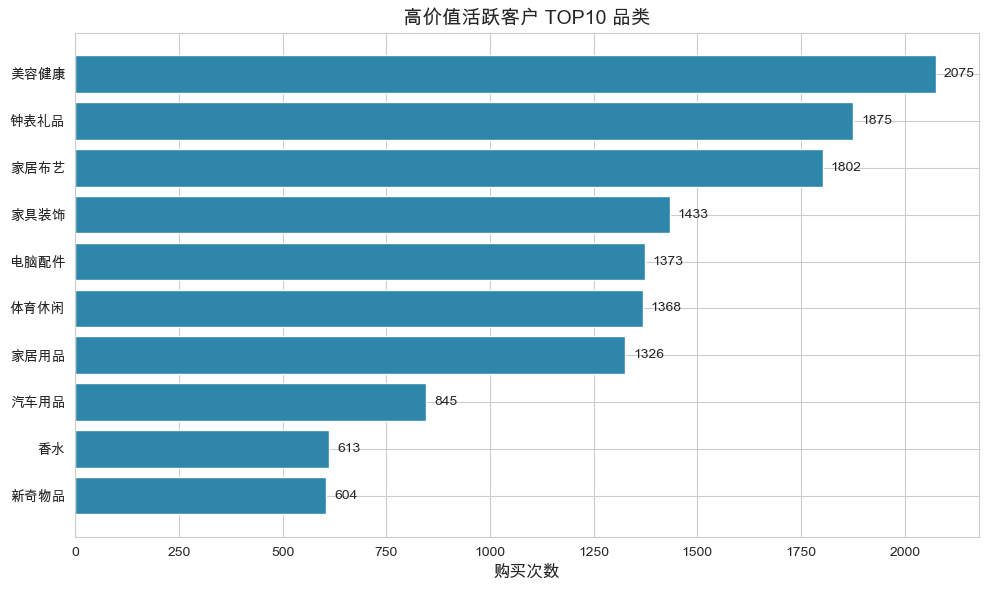

In [34]:

plt.rcParams['font.sans-serif'] = ['Heiti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 品类中文映射
category_names_cn = {
    'beleza_saude': '美容健康',
    'relogios_presentes': '钟表礼品',
    'cama_mesa_banho': '家居布艺',
    'moveis_decoracao': '家具装饰',
    'informatica_acessorios': '电脑配件',
    'esporte_lazer': '体育休闲',
    'utilidades_domesticas': '家居用品',
    'automotivo': '汽车用品',
    'perfumaria': '香水',
    'cool_stuff': '新奇物品'
}

# 准备数据
categories = list(high_value_category.index)[:10]
counts = list(high_value_category.values)[:10]
categories_cn = [category_names_cn.get(cat, cat) for cat in categories]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(categories_cn, counts, color='#2E86AB')
ax.set_title('高价值活跃客户 TOP10 品类', fontsize=14, fontweight='bold')
ax.set_xlabel('购买次数', fontsize=12)

# 添加数值标签
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{int(bar.get_width())}', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.show()